In [1]:
import pandas as pd 
import re

In [2]:
df = pd.read_csv("../data/products_asos.csv")

df.head(5)

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [3]:
df.isnull().sum() #----> 18 per column
df.duplicated().sum() #----> 343 duplicates

np.int64(343)

DATA CLEANING

In [4]:
#Removing nan values
df = df.dropna()

#Removing duplicates
df = df.drop_duplicates()

#removing text from price
df["price"] = df["price"].str.replace("From", "", regex=False)
df["price"] = df["price"].str.replace("Now", "", regex=False).astype(float)

df["color"] = df["color"].str.lower()

#Separating brand and the name
exceptions = ["4th & Reckless", "Y.A.S", "Pull&Bear", "ASOS 4505", "NA-KD x Angelica"]

def extract_brand(text):
    #looking through exceptions
    for brand in exceptions:
        if re.match(re.escape(brand), text, re.IGNORECASE):
            return brand
    
    match = re.match(r'^([A-Za-z]+(?:\s[A-Z][A-Za-z]*)*)', text)
    if match:
        return match.group(1)
    else:
        return "others"
    
df["brand"] = df["name"].apply(extract_brand)
    
#creating styles columns
def detect_category(text):
    text = text.lower()
    
    if "dress" in text:
        return "dress"
    elif "top" in text or "t-shirt" in text or "tee" in text:
        return "top"
    elif "jacket" in text or "coat" in text or "bomber" in text :
        return "outerwear"
    elif "trouser" in text or "jeans" in text or "short" in text:
        return "bottom"
    elif "skirt" in text:
        return "skirt"
    else:
        return "other"
    
df["category"] = df["name"].apply(detect_category)

In [5]:
df = df.drop_duplicates()

df

,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",outerwear,49.99,neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",outerwear,49.99,neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",outerwear,49.99,neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",outerwear,49.99,neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",outerwear,59.99,grey,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius
...,...,...,...,...,...,...,...,...,...,...
30840,https://www.asos.com/urban-revivo/urban-revivo...,Urban Revivo square neck mini dress in floral ...,"XS - UK 6 - Out of stock,S - UK 8 - Out of sto...",dress,44.00,multi,116745746.0,[{'Product Details': 'Mini dress by Urban Revi...,['https://images.asos-media.com/products/urban...,Urban Revivo
30841,https://www.asos.com/asos-design/asos-design-l...,ASOS DESIGN long sleeve maxi t-shirt dress in ...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",dress,24.00,black,1444255.0,[{'Product Details': 'Dress by ASOS DESIGN Act...,['https://images.asos-media.com/products/asos-...,ASOS DESIGN
30842,https://www.asos.com/asyou/asyou-layered-t-shi...,ASYOU layered t-shirt dress with focus graphic...,"UK 4 - Out of stock,UK 6,UK 8 - Out of stock,U...",dress,22.99,washed black,110783769.0,[{'Product Details': 'Dress by ASYOU Exclusive...,['https://images.asos-media.com/products/asyou...,ASYOU
30843,https://www.asos.com/miss-selfridge/miss-selfr...,Miss Selfridge Petite rib knit frill hem funne...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",dress,32.99,black,116363729.0,[{'Product Details': 'Petite by Miss Selfridge...,['https://images.asos-media.com/products/miss-...,Miss Selfridge Petite


In [6]:
#counting words that comes the most in a column for creating a new column/feature
from collections import Counter

all_words = " ".join(df["name"].str.lower()).split()
Counter(all_words).most_common(10)

[('in', 30571),
 ('dress', 10999),
 ('asos', 8299),
 ('black', 7148),
 ('design', 7019),
 ('with', 5984),
 ('mini', 4376),
 ('sleeve', 4076),
 ('midi', 3657),
 ('top', 3556)]

In [11]:
df["size"]


0        UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...
1        UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...
2        UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...
3        UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...
4        XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14
                               ...                        
30840    XS - UK 6 - Out of stock,S - UK 8 - Out of sto...
30841    UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...
30842    UK 4 - Out of stock,UK 6,UK 8 - Out of stock,U...
30843    UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...
30844    XS - UK 4-6 - Out of stock,S - UK 8-10,M - UK ...
Name: size, Length: 30501, dtype: object

In [ ]:
df = df.drop(columns=["description","images","sku","url", "name"])


df = df.dropna()

df.to_csv("powerbi_products_asos.csv", index=False)

DATA ANALYSIS

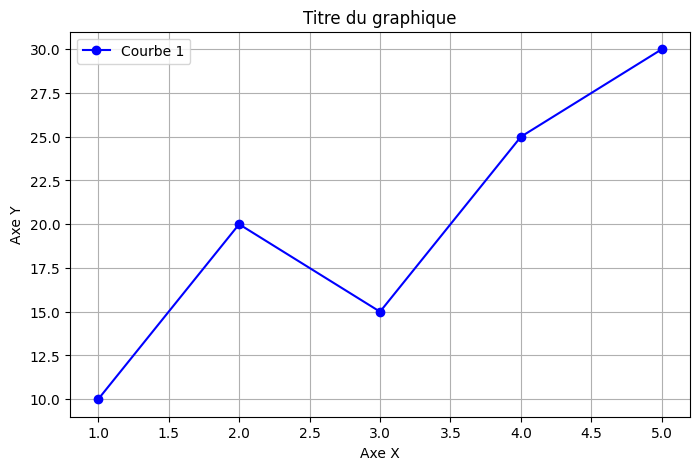

In [9]:
import matplotlib.pyplot as plt


x = [1, 2, 3, 4, 5]
y = [10, 20, 15, 25, 30]  # ordonnées

# 2️⃣ Créer la figure et les axes
plt.figure(figsize=(8, 5))  # taille de la figure

# 3️⃣ Tracer les données
plt.plot(x, y, label='Courbe 1', color='blue', marker='o')  # ligne avec marqueurs

# 4️⃣ Ajouter titre et labels
plt.title("Titre du graphique")
plt.xlabel("Axe X")
plt.ylabel("Axe Y")

# 5️⃣ Ajouter la légende
plt.legend()

# 6️⃣ Ajouter une grille
plt.grid(True)

# 7️⃣ Afficher le plot
plt.show()